In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

# Drive'ı bağla
drive.mount('/content/drive')

# Dosya yolunu belirle ve veriyi oku
path = '/content/drive/MyDrive/teleCust1000t.csv'
df = pd.read_csv(path)

# Veriye hızlıca bir göz atalım
print(df.head())
print("\nSınıf Dağılımı:\n", df['custcat'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   region  tenure  age  marital  address  income  ed  employ  retire  gender  \
0       2      13   44        1        9    64.0   4       5     0.0       0   
1       3      11   33        1        7   136.0   5       5     0.0       0   
2       3      68   52        1       24   116.0   1      29     0.0       1   
3       2      33   33        0       12    33.0   2       0     0.0       1   
4       2      23   30        1        9    30.0   1       2     0.0       0   

   reside  custcat  
0       2        1  
1       6        4  
2       2        3  
3       1        1  
4       4        3  

Sınıf Dağılımı:
 custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64


In [6]:
# Bağımsız değişkenleri (X) ve hedef değişkeni (y) ayır
X = df[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']].values
y = df['custcat'].values

# Normalizasyon (StandardScaler)
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))

# Eğitim ve Test setlerine ayır (%20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print('Eğitim seti yapısı:', X_train.shape)

Eğitim seti yapısı: (800, 11)


In [7]:
def knn_deney(k_degeri):
    model = KNeighborsClassifier(n_neighbors = k_degeri).fit(X_train, y_train)
    tahmin = model.predict(X_test)
    acc = metrics.accuracy_score(y_test, tahmin)
    f1 = metrics.f1_score(y_test, tahmin, average='weighted')
    print(f"k={k_degeri} için -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

knn_deney(4)
knn_deney(6)

k=4 için -> Accuracy: 0.3200, F1-Score: 0.3116
k=6 için -> Accuracy: 0.3100, F1-Score: 0.3010


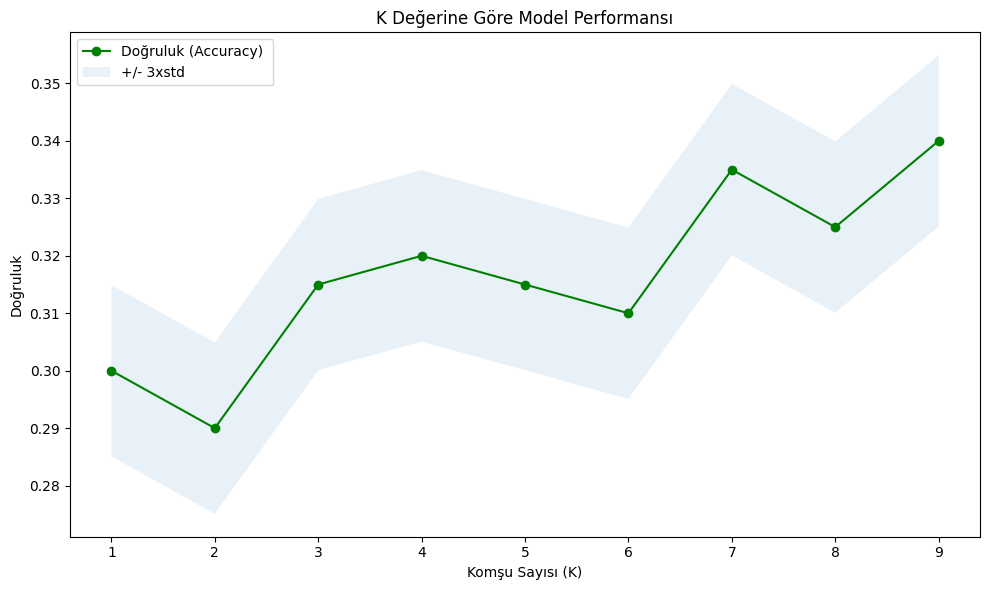


En iyi sonuç: 0.3400 doğruluğu ile k=9 değerinde alındı.


In [8]:
Ks = 10
mean_acc = np.zeros((Ks-1))

for n in range(1, Ks):
    # Modeli eğit ve tahmin yap
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train, y_train)
    y_pred = neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, y_pred)

# Grafiği çizdir
plt.figure(figsize=(10,6))
plt.plot(range(1,Ks), mean_acc, 'g', marker='o')
plt.fill_between(range(1,Ks), mean_acc - 1 * np.std(mean_acc), mean_acc + 1 * np.std(mean_acc), alpha=0.10)
plt.legend(('Doğruluk (Accuracy) ', '+/- 3xstd'))
plt.ylabel('Doğruluk')
plt.xlabel('Komşu Sayısı (K)')
plt.title('K Değerine Göre Model Performansı')
plt.tight_layout()
plt.show()

print(f"\nEn iyi sonuç: {mean_acc.max():.4f} doğruluğu ile k={mean_acc.argmax()+1} değerinde alındı.")

/tmp/ipykernel_3750/3116273123.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='custcat', data=df, palette='viridis')


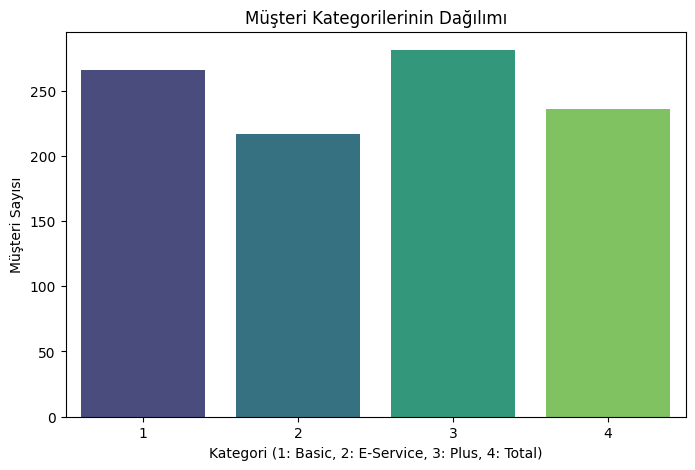

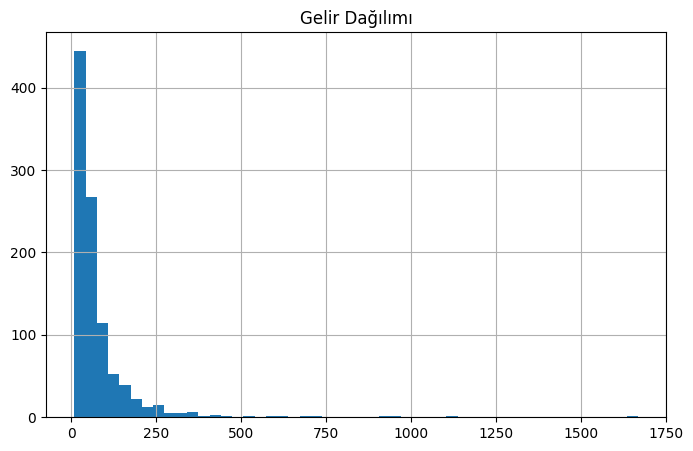

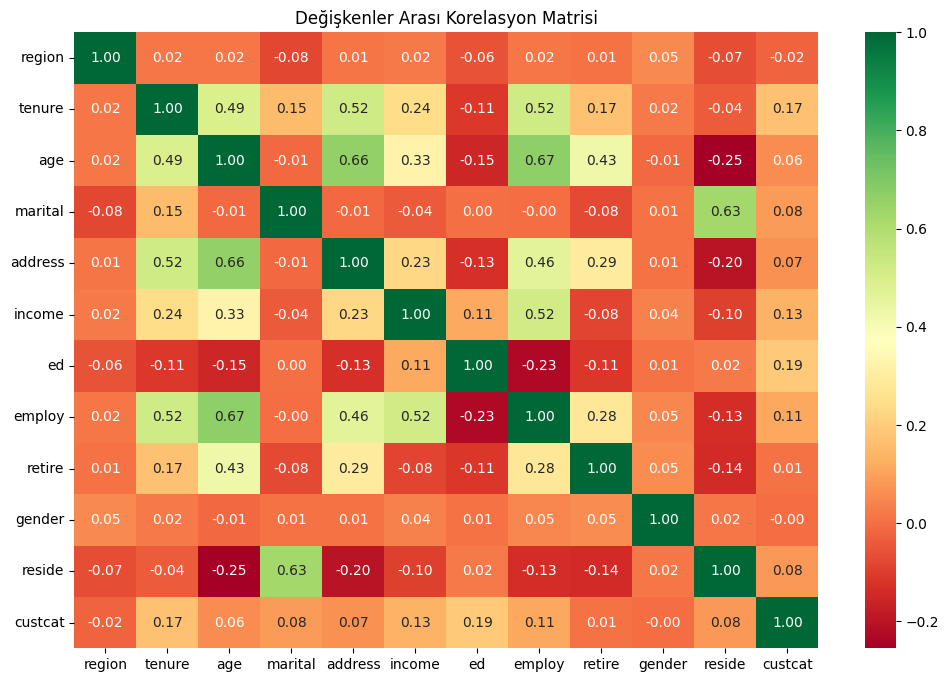

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sınıf Dağılımı (Bar Plot) - Föyde istenen analiz
plt.figure(figsize=(8, 5))
sns.countplot(x='custcat', data=df, palette='viridis')
plt.title('Müşteri Kategorilerinin Dağılımı')
plt.xlabel('Kategori (1: Basic, 2: E-Service, 3: Plus, 4: Total)')
plt.ylabel('Müşteri Sayısı')
plt.show()

# 2. Değişkenlerin Dağılımı (Histogramlar)
df.hist(column='income', bins=50, figsize=(8,5))
plt.title('Gelir Dağılımı')
plt.show()

# 3. Özellikler Arası Korelasyon Isı Haritası
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

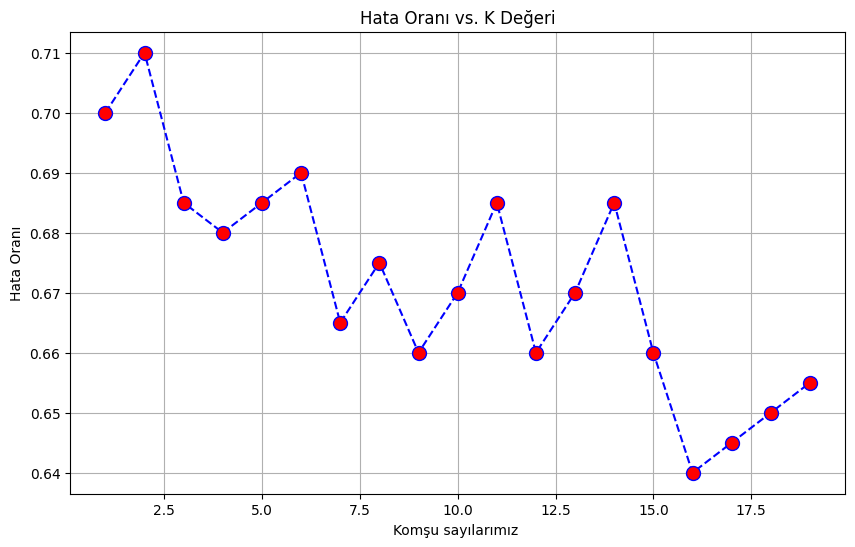

In [13]:
error_rate = []

# 1'den 20'ye kadar k değerlerini test edelim
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Hata Oranı vs. K Değeri')
plt.xlabel('Komşu sayılarımız ')
plt.ylabel('Hata Oranı')
plt.grid(True)
plt.show()